# Last Mile Logistics Auditor

**Client:** Veridi Logistics  
**Dataset:** Olist Brazilian E-Commerce Public Dataset  
**Objective:** Audit delivery performance to determine whether late deliveries are a regional or nationwide issue, and quantify their impact on customer satisfaction.

This notebook joins four relational tables (orders, reviews, customers, products), computes the gap between estimated and actual delivery dates, and links delivery performance to customer review scores.

## 1. Imports & Setup

Standard scientific Python stack. Visualization is done with matplotlib only (no seaborn) to keep dependencies minimal.

In [1]:
import os, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Relative path to the Kaggle CSVs.
DATA_DIR = "data"

print("Environment ready.")

Environment ready.


In [2]:
# auto-download data from Kaggle
required = ["olist_orders_dataset.csv", "olist_order_reviews_dataset.csv",
            "olist_customers_dataset.csv", "olist_products_dataset.csv",
            "product_category_name_translation.csv"]

if all(os.path.exists(f"data/{f}") for f in required):
    print("All data files present")
else:
    try:
        os.makedirs("data", exist_ok=True)
        subprocess.run(
            ["kaggle", "datasets", "download", "-d", "olistbr/brazilian-ecommerce",
             "-p", "data", "--unzip"],
            check=True
        )
        print("Downloaded and extracted to data/")
    except (FileNotFoundError, subprocess.CalledProcessError) as e:
        print("Auto-download failed. Manual setup required:")
        print("1. Download: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce")
        print("2. Unzip CSVs into ./data/")
        print(f"(Reason: {e})")

All data files present


## 2. Data Loading

We load four CSVs from the Olist relational dataset using **relative paths** rooted at `./data/`. A small helper joins the directory and filename, checks the file exists (with an actionable error message if not), and reports the shape on load.

In [3]:
def load_csv(filename: str) -> pd.DataFrame:
    """Load a CSV from DATA_DIR, fail loudly if missing, and report shape."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Could not find '{path}'. "
            f"Download the Olist dataset from "
            f"https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce "
            f"and place the CSVs in the './{DATA_DIR}/' folder."
        )
    df = pd.read_csv(path)
    print(f"{filename:<45} -> {df.shape[0]:>7,} rows x {df.shape[1]:>2} cols")
    return df

orders    = load_csv("olist_orders_dataset.csv")
reviews   = load_csv("olist_order_reviews_dataset.csv")
customers = load_csv("olist_customers_dataset.csv")
products  = load_csv("olist_products_dataset.csv")

olist_orders_dataset.csv                      ->  99,441 rows x  8 cols
olist_order_reviews_dataset.csv               ->  99,224 rows x  7 cols
olist_customers_dataset.csv                   ->  99,441 rows x  5 cols
olist_products_dataset.csv                    ->  32,951 rows x  9 cols


Quick peek at the central `orders` table to confirm the columns we will rely on for delay computation.

In [4]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## 3. Data Cleaning

Three things happen here:

1. **Date columns are parsed to `datetime`.** Without this, subtraction between estimated and actual delivery dates is impossible.
2. **Non-delivered orders are removed.** Orders with status `canceled`, `unavailable`, `created`, `approved`, `invoiced`, `processing`, or `shipped` either never reached the customer or are still in transit. They have no `order_delivered_customer_date` and would corrupt delay analysis. We retain only `delivered` orders. This is documented as an explicit business decision below.
3. **Missing delivery timestamps** on the remaining `delivered` rows (a small handful of data-quality issues) are dropped.

In [5]:
DATE_COLS = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in DATE_COLS:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

print("Order status distribution (raw):")
print(orders["order_status"].value_counts())

Order status distribution (raw):
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [6]:
# Decision: keep only orders that actually reached the customer.
# Other statuses lack a delivery timestamp and cannot be evaluated for delay.
n_before = len(orders)
orders = orders[orders["order_status"] == "delivered"].copy()
n_after = len(orders)
print(f"Filtered to delivered orders: {n_before:,} -> {n_after:,} "
      f"(removed {n_before - n_after:,})")

# A small number of 'delivered' orders still have null delivery timestamps.
# These are data-quality issues and cannot be used for delay computation.
missing_delivery = orders["order_delivered_customer_date"].isna().sum()
print(f"Delivered orders missing actual delivery date: {missing_delivery}")

orders = orders.dropna(subset=["order_delivered_customer_date",
                                "order_estimated_delivery_date"]).copy()
print(f"Final clean order count: {len(orders):,}")

Filtered to delivered orders: 99,441 -> 96,478 (removed 2,963)
Delivered orders missing actual delivery date: 8
Final clean order count: 96,470


## 4. Data Joining

We build a single master table by joining `reviews` and `customers` onto the cleaned `orders` table.

**Critical guard:** the reviews table has a 1-to-many relationship with orders (a customer can leave more than one review per order). To prevent accidental row inflation, we keep **the latest review per `order_id`** before joining. The row count of the master dataframe must equal the row count of cleaned `orders`.

In [7]:
def latest_review_per_order(reviews_df: pd.DataFrame) -> pd.DataFrame:
    """Collapse multi-review orders to a single row using the latest creation date."""
    reviews_df = reviews_df.copy()
    reviews_df["review_creation_date"] = pd.to_datetime(
        reviews_df["review_creation_date"], errors="coerce"
    )
    return (reviews_df
            .sort_values("review_creation_date")
            .drop_duplicates(subset="order_id", keep="last"))

reviews_unique = latest_review_per_order(reviews)
print(f"Reviews: {len(reviews):,} -> {len(reviews_unique):,} after dedup on order_id")

Reviews: 99,224 -> 98,673 after dedup on order_id


In [8]:
def join_master(orders_df, reviews_df, customers_df):
    """Build the master dataset; assert no row inflation."""
    expected_rows = len(orders_df)

    df = orders_df.merge(reviews_df, on="order_id", how="left")
    assert len(df) == expected_rows, "Row count changed after reviews join"

    df = df.merge(customers_df, on="customer_id", how="left")
    assert len(df) == expected_rows, "Row count changed after customers join"

    return df

master = join_master(orders, reviews_unique, customers)
print(f"Master dataset: {len(master):,} rows x {master.shape[1]} cols")
print(f"Orders with a review attached: {master['review_score'].notna().sum():,} "
      f"({master['review_score'].notna().mean()*100:.1f}%)")

Master dataset: 96,470 rows x 18 cols
Orders with a review attached: 95,824 (99.3%)


## 5. Feature Engineering

We compute the headline metric of this audit:

- **`Days_Difference`** = `order_estimated_delivery_date` − `order_delivered_customer_date`  
  - **Positive** ⇒ delivered *before* the promised date (good).  
  - **Negative** ⇒ delivered *after* the promised date (late).

To avoid sign confusion downstream, we also create **`Delay_Days`** = −`Days_Difference`. Positive `Delay_Days` means the package was that many days late.

We then bucket orders into three delivery statuses:

| Status      | Rule                              |
|-------------|-----------------------------------|
| On Time     | `Delay_Days <= 0`                 |
| Late        | `0 < Delay_Days <= 5`             |
| Super Late  | `Delay_Days > 5`                  |

In [9]:
def compute_delivery_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Days_Difference"] = (
        df["order_estimated_delivery_date"] - df["order_delivered_customer_date"]
    ).dt.days
    df["Delay_Days"] = -df["Days_Difference"]

    def classify(delay):
        if delay <= 0:
            return "On Time"
        elif delay <= 5:
            return "Late"
        else:
            return "Super Late"

    df["Delivery_Status"] = df["Delay_Days"].apply(classify)
    return df

master = compute_delivery_features(master)
master[["order_id", "Days_Difference", "Delay_Days", "Delivery_Status"]].head()

,order_id,Days_Difference,Delay_Days,Delivery_Status
0,e481f51cbdc54678b7cc49136f2d6af7,7,-7,On Time
1,53cdb2fc8bc7dce0b6741e2150273451,5,-5,On Time
2,47770eb9100c2d0c44946d9cf07ec65d,17,-17,On Time
3,949d5b44dbf5de918fe9c16f97b45f8a,12,-12,On Time
4,ad21c59c0840e6cb83a9ceb5573f8159,9,-9,On Time


## 6. Exploratory Analysis

### 6.A Distribution of Delivery Delays

Histogram of `Delay_Days`. Negative values = early; positive values = late. We clip the x-axis to the 1st–99th percentile to keep the chart readable (a few extreme outliers exist but are not informative for the bulk distribution).

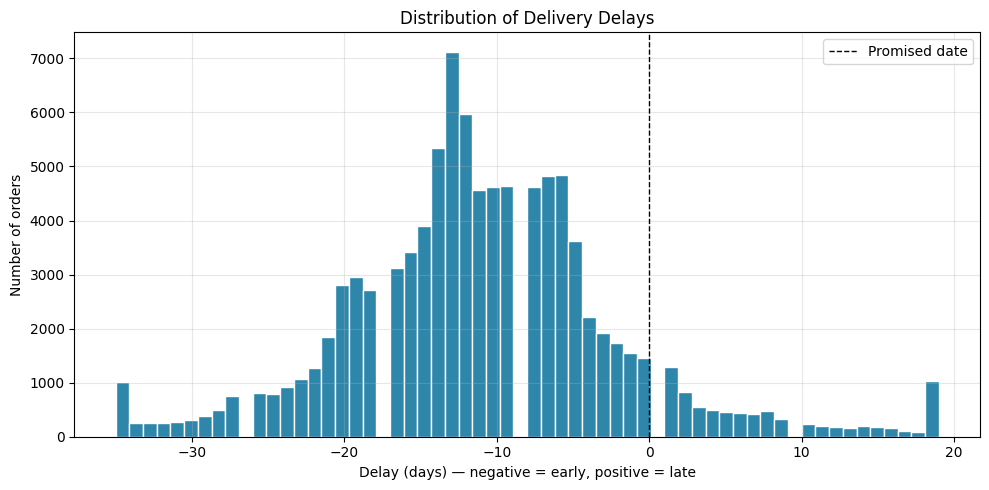

count    96470.00
mean       -10.88
std         10.18
min       -146.00
25%        -16.00
50%        -11.00
75%         -6.00
max        189.00
Name: Delay_Days, dtype: float64


In [10]:
fig, ax = plt.subplots()
lo, hi = master["Delay_Days"].quantile([0.01, 0.99])
ax.hist(master["Delay_Days"].clip(lo, hi), bins=60,
        color="#2E86AB", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", linewidth=1, label="Promised date")
ax.set_xlabel("Delay (days) — negative = early, positive = late")
ax.set_ylabel("Number of orders")
ax.set_title("Distribution of Delivery Delays")
ax.legend()
plt.tight_layout()
plt.show()

print(master["Delay_Days"].describe().round(2))

### 6.B Count of Each Delivery Status

                 orders  share_pct
Delivery_Status                   
On Time           88644      91.89
Late               3615       3.75
Super Late         4211       4.37


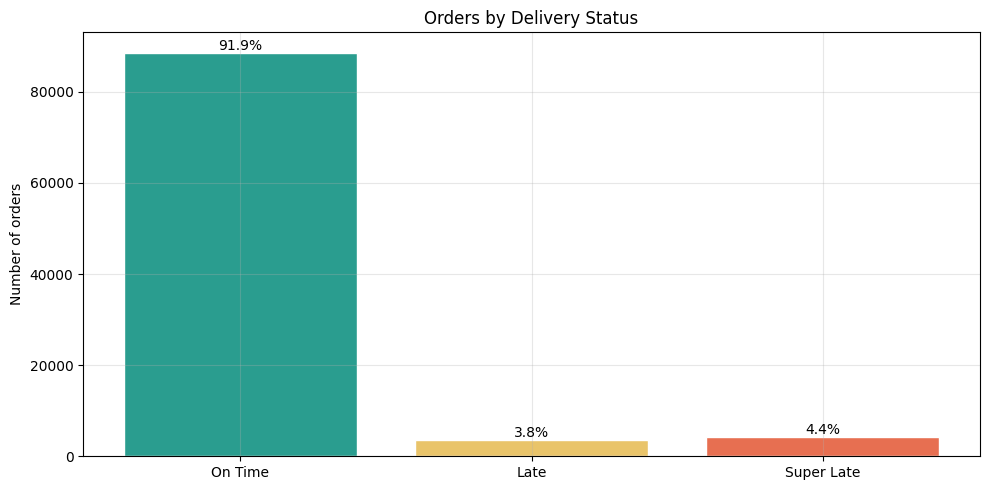

In [11]:
status_order = ["On Time", "Late", "Super Late"]
status_counts = master["Delivery_Status"].value_counts().reindex(status_order)
status_pct = (status_counts / status_counts.sum() * 100).round(2)

summary_status = pd.DataFrame({"orders": status_counts, "share_pct": status_pct})
print(summary_status)

fig, ax = plt.subplots()
colors = ["#2A9D8F", "#E9C46A", "#E76F51"]
bars = ax.bar(status_counts.index, status_counts.values, color=colors,
              edgecolor="white")
for bar, pct in zip(bars, status_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of orders")
ax.set_title("Orders by Delivery Status")
plt.tight_layout()
plt.show()

## 7. Geographic Analysis

We group by `customer_state` and compute the share of orders that were Late or Super Late. This directly answers the CEO's question: *"Are we failing specific regions, or is this a nationwide problem?"*

In [12]:
def state_late_rate(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby("customer_state").agg(
        total_orders=("order_id", "count"),
        late_orders=("Delivery_Status",
                     lambda s: (s.isin(["Late", "Super Late"])).sum()),
        super_late_orders=("Delivery_Status",
                           lambda s: (s == "Super Late").sum()),
    )
    g["pct_late"] = (g["late_orders"] / g["total_orders"] * 100).round(2)
    g["pct_super_late"] = (g["super_late_orders"] / g["total_orders"] * 100).round(2)
    return g.sort_values("pct_late", ascending=False)

state_perf = state_late_rate(master)
state_perf.head(10)

,total_orders,late_orders,super_late_orders,pct_late,pct_super_late
customer_state,,,,,
AL,397,95,57,23.93,14.36
MA,717,141,81,19.67,11.30
PI,476,76,42,15.97,8.82
CE,1279,196,142,15.32,11.10
SE,335,51,41,15.22,12.24
BA,3256,457,278,14.04,8.54
RJ,12350,1664,1122,13.47,9.09
TO,274,35,19,12.77,6.93
PA,946,117,85,12.37,8.99


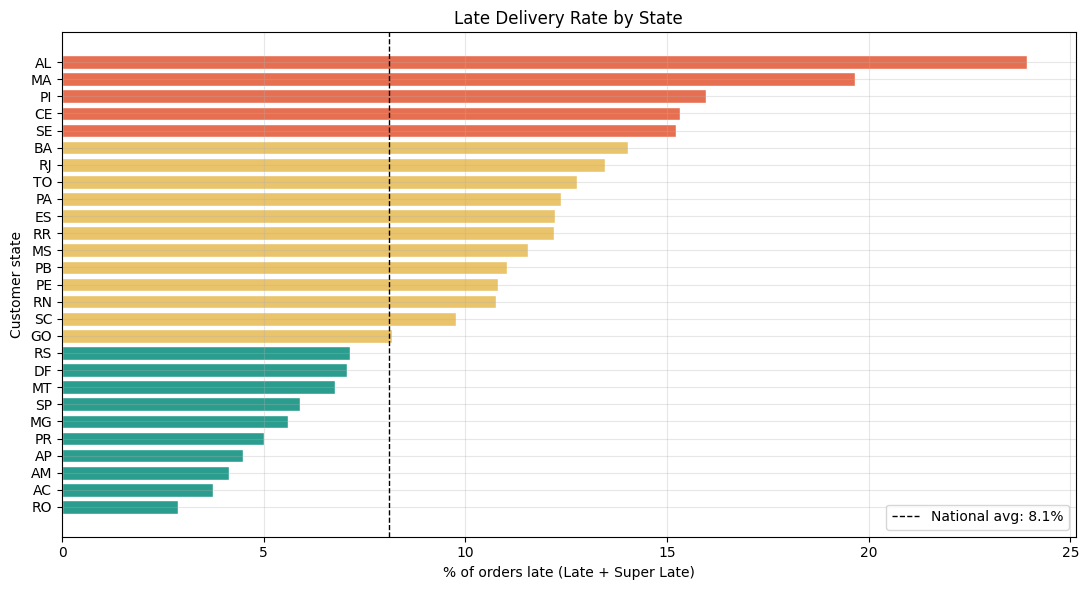

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
sorted_states = state_perf.sort_values("pct_late", ascending=True)
colors = ["#E76F51" if v >= 15 else "#E9C46A" if v >= 8 else "#2A9D8F"
          for v in sorted_states["pct_late"]]
ax.barh(sorted_states.index, sorted_states["pct_late"], color=colors,
        edgecolor="white")
ax.set_xlabel("% of orders late (Late + Super Late)")
ax.set_ylabel("Customer state")
ax.set_title("Late Delivery Rate by State")
nat_avg = (master["Delivery_Status"].isin(["Late", "Super Late"]).mean() * 100)
ax.axvline(nat_avg, color="black", linestyle="--", linewidth=1,
           label=f"National avg: {nat_avg:.1f}%")
ax.legend()
plt.tight_layout()
plt.show()

**Observation.** A handful of states sit well above the national average, while the majority cluster around it. This is consistent with a *regional* problem rather than a uniform nationwide failure see the Final Insights section for a precise statement.

## 8. Sentiment Analysis

Two complementary views:

1. **Average review score by Delivery_Status**  does being late actually move the score?
2. **Scatter of `Delay_Days` vs `review_score`**  what is the shape of the relationship across the full delay range?

                 mean  count
Delivery_Status             
On Time          4.29  88163
Late             3.46   3568
Super Late       1.78   4093


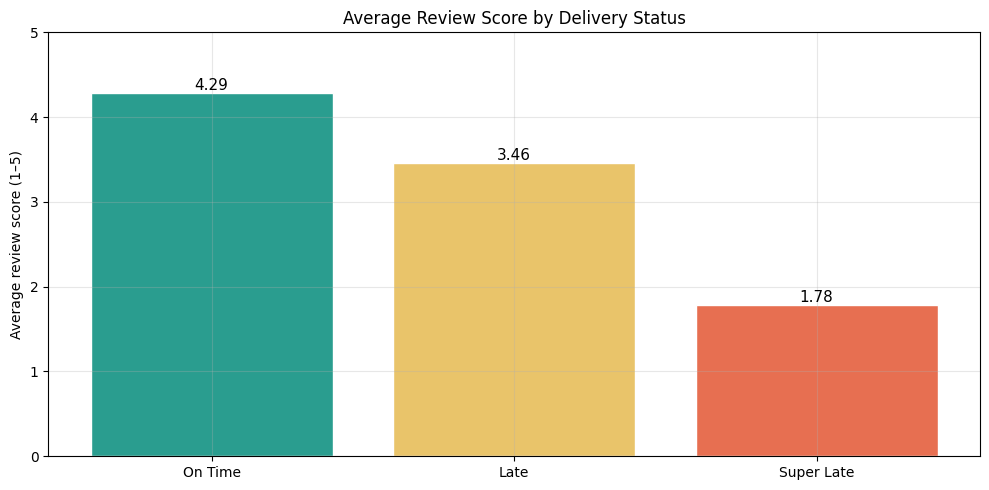

In [14]:
sentiment = (master.dropna(subset=["review_score"])
                   .groupby("Delivery_Status")["review_score"]
                   .agg(["mean", "count"])
                   .reindex(status_order))
sentiment["mean"] = sentiment["mean"].round(2)
print(sentiment)

fig, ax = plt.subplots()
bars = ax.bar(sentiment.index, sentiment["mean"],
              color=["#2A9D8F", "#E9C46A", "#E76F51"], edgecolor="white")
for bar, val in zip(bars, sentiment["mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val:.2f}", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Average review score (1–5)")
ax.set_title("Average Review Score by Delivery Status")
ax.set_ylim(0, 5)
plt.tight_layout()
plt.show()

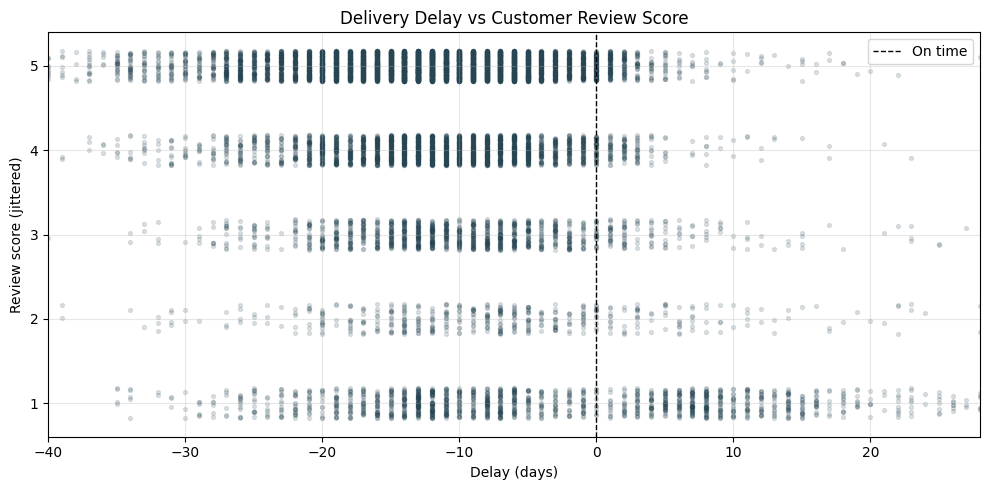

Pearson correlation (Delay_Days, review_score): -0.267


In [15]:
# Scatter: Delay_Days vs review_score
# review_score is integer 1-5, so we add light vertical jitter for readability.
# We sample for plotting speed; cap at the size of the available reviewed-orders frame.
reviewed = master.dropna(subset=["review_score"])
sample = reviewed.sample(n=min(15000, len(reviewed)), random_state=RANDOM_STATE)
jitter = np.random.uniform(-0.18, 0.18, len(sample))

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample["Delay_Days"], sample["review_score"] + jitter,
           alpha=0.15, s=8, color="#264653")
ax.axvline(0, color="black", linestyle="--", linewidth=1, label="On time")
ax.set_xlabel("Delay (days)")
ax.set_ylabel("Review score (jittered)")
ax.set_title("Delivery Delay vs Customer Review Score")
ax.set_xlim(master["Delay_Days"].quantile(0.005),
            master["Delay_Days"].quantile(0.995))
ax.legend()
plt.tight_layout()
plt.show()

corr = master[["Delay_Days", "review_score"]].dropna().corr().iloc[0, 1]
print(f"Pearson correlation (Delay_Days, review_score): {corr:.3f}")

## 9. Bonus — Product Category Translation

The `product_category_name` column is in Portuguese. We attempt to load `product_category_name_translation.csv` (shipped with the Olist dataset) and join it.

In [16]:
translation_file = os.path.join(DATA_DIR, "product_category_name_translation.csv")

if os.path.exists(translation_file):
    cat_translation = pd.read_csv(translation_file)
    products_en = products.merge(cat_translation,
                                 on="product_category_name", how="left")
    # Build order -> category(EN) lookup via the order_items table if available;
    # otherwise we just demonstrate translation coverage at the product level.
    coverage = products_en["product_category_name_english"].notna().mean()
    print(f"Translation coverage: {coverage*100:.1f}% of products mapped to English.")
    print(products_en[["product_category_name",
                       "product_category_name_english"]].dropna().head(8))
else:
    print(f"'{translation_file}' not found in working directory.")
    print("Limitation: product categories remain in Portuguese in this run.")
    print("To enable translation, place the file alongside the notebook and re-run.")

Translation coverage: 98.1% of products mapped to English.
   product_category_name product_category_name_english
0             perfumaria                     perfumery
1                  artes                           art
2          esporte_lazer                sports_leisure
3                  bebes                          baby
4  utilidades_domesticas                    housewares
5  instrumentos_musicais           musical_instruments
6             cool_stuff                    cool_stuff
7       moveis_decoracao               furniture_decor


## 10. Candidate's Choice Promise Gap by State

**The added analysis.** For each state we compute the **median promise gap**: how many days in advance did Veridi *promise* the package would arrive, relative to when it actually arrived? Specifically:

- **`Promise_Gap`** = `order_estimated_delivery_date`,  `order_purchase_timestamp` (days the customer was told to wait).
- **`Actual_Time`** = `order_delivered_customer_date`,  `order_purchase_timestamp` (days they actually waited).

A state where the promise is short *and* the late rate is high is a state where Veridi is **structurally over-promising**. This is more actionable than the late-rate alone, because it tells operations *whether to fix the carrier* (close the gap on actuals) or *fix the website's delivery estimator* (lengthen the promise).

**Why this matters to the business.** The CEO's hypothesis is that the company is "over-promising and under-delivering." The standard late-rate chart shows *where* it's bad, but not *why*. This breakdown isolates the two levers: estimator accuracy vs. carrier performance.

In [17]:
def promise_gap_by_state(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["Promise_Gap"] = (df["order_estimated_delivery_date"]
                         - df["order_purchase_timestamp"]).dt.days
    df["Actual_Time"] = (df["order_delivered_customer_date"]
                         - df["order_purchase_timestamp"]).dt.days
    g = df.groupby("customer_state").agg(
        median_promised_days=("Promise_Gap", "median"),
        median_actual_days=("Actual_Time", "median"),
        pct_late=("Delivery_Status",
                  lambda s: s.isin(["Late", "Super Late"]).mean() * 100),
        n_orders=("order_id", "count"),
    ).round(2)
    g["promise_minus_actual"] = (g["median_promised_days"]
                                  - g["median_actual_days"]).round(2)
    return g.sort_values("pct_late", ascending=False)

gap = promise_gap_by_state(master)
print(gap.head(10))

                median_promised_days  median_actual_days  pct_late  n_orders  promise_minus_actual
customer_state                                                                                    
AL                              31.0                22.0     23.93       397                   9.0
MA                              30.0                19.0     19.67       717                  11.0
PI                              29.0                16.0     15.97       476                  13.0
CE                              31.0                18.0     15.32      1279                  13.0
SE                              29.0                18.0     15.22       335                  11.0
BA                              29.0                16.0     14.04      3256                  13.0
RJ                              24.0                12.0     13.47     12350                  12.0
TO                              28.0                15.0     12.77       274                  13.0
PA        

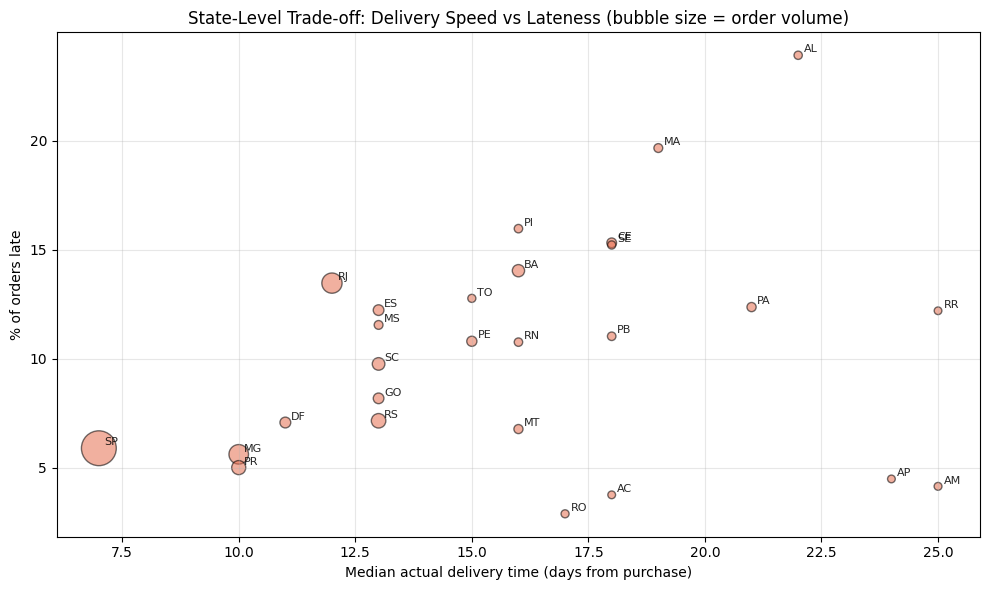

In [18]:
# Scatter: median delivery time vs late rate, sized by volume.
fig, ax = plt.subplots(figsize=(10, 6))
sizes = (gap["n_orders"] / gap["n_orders"].max() * 600) + 30
ax.scatter(gap["median_actual_days"], gap["pct_late"],
           s=sizes, alpha=0.55, color="#E76F51", edgecolor="black")
for state, row in gap.iterrows():
    ax.annotate(state, (row["median_actual_days"], row["pct_late"]),
                fontsize=8, alpha=0.85,
                xytext=(4, 2), textcoords="offset points")
ax.set_xlabel("Median actual delivery time (days from purchase)")
ax.set_ylabel("% of orders late")
ax.set_title("State-Level Trade-off: Delivery Speed vs Lateness "
             "(bubble size = order volume)")
plt.tight_layout()
plt.show()

**Reading the chart.** States in the top-right quadrant are the danger zone: customers wait a long time *and* the package still misses the promise. These are the priority states for either carrier renegotiation or estimator recalibration.

In [19]:
# DASHBOARD DATA EXPORT
# Run this cell ONCE in your notebook (after Section 10 — Candidate's Choice)
# to produce the CSV that the Streamlit dashboard reads.
#
# Output: ./data/master_dataset.csv (~25-30 MB, gitignored)

# Build the dashboard-ready dataframe from the master table you already have
# in scope. Includes all columns the dashboard needs, nothing it doesn't.
dashboard_cols = [
    "order_id",
    "customer_state",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "Days_Difference",
    "Delay_Days",
    "Delivery_Status",
    "review_score",
]

# Pull product category in English (uses Section 9 translation if available)
# We need to attach the dominant category per order. This requires the
# order_items table from Olist (small file, ~16 MB).
items_path = os.path.join(DATA_DIR, "olist_order_items_dataset.csv")
trans_path = os.path.join(DATA_DIR, "product_category_name_translation.csv")

if os.path.exists(items_path) and os.path.exists(trans_path):
    items = pd.read_csv(items_path)
    translation = pd.read_csv(trans_path)

    # one product per order = the first item (most orders are single-item anyway)
    first_item = items.sort_values("order_item_id").drop_duplicates(
        "order_id", keep="first"
    )[["order_id", "product_id"]]

    # attach product category, then translate
    cat_map = products[["product_id", "product_category_name"]].merge(
        translation, on="product_category_name", how="left"
    )
    cat_map = cat_map[["product_id", "product_category_name_english"]].rename(
        columns={"product_category_name_english": "product_category"}
    )

    order_category = first_item.merge(cat_map, on="product_id", how="left")
    export_df = master.merge(
        order_category[["order_id", "product_category"]], on="order_id", how="left"
    )
    dashboard_cols.append("product_category")
else:
    print("Note: order_items or translation file not found. "
          "Dashboard will run without product category breakdown.")
    export_df = master.copy()

# Add Promise Gap features (used by the candidate's choice chart)
export_df["Promise_Gap_Days"] = (
    export_df["order_estimated_delivery_date"]
    - export_df["order_purchase_timestamp"]
).dt.days
export_df["Actual_Time_Days"] = (
    export_df["order_delivered_customer_date"]
    - export_df["order_purchase_timestamp"]
).dt.days
dashboard_cols.extend(["Promise_Gap_Days", "Actual_Time_Days"])

# Subset and write
final = export_df[dashboard_cols].copy()
out_path = os.path.join(DATA_DIR, "master_dataset.csv")
final.to_csv(out_path, index=False)

print(f"Wrote {out_path}")
print(f"Rows: {len(final):,}, Columns: {len(final.columns)}")
print(f"File size: {os.path.getsize(out_path) / 1e6:.1f} MB")
print(f"\nColumn summary:")
print(final.dtypes)


Wrote data\master_dataset.csv
Rows: 96,470, Columns: 12
File size: 12.1 MB

Column summary:
order_id                                 object
customer_state                           object
order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
Days_Difference                           int64
Delay_Days                                int64
Delivery_Status                          object
review_score                            float64
product_category                         object
Promise_Gap_Days                          int64
Actual_Time_Days                          int64
dtype: object


## 11. Final Insights

- **The problem is regional, not nationwide.** The national late rate is **8.11%** (3,615 Late + 4,211 Super Late out of 96,470 delivered orders). Alagoas (AL) tops the list at **23.93%**, almost **3x the national average**, followed by Maranhao (19.67%), Piaui (15.97%) and Ceara (15.32%). All four are remote Northern/Northeastern states. The dominant Sao Paulo market sits well below average. This is a concentrated regional failure, not a system-wide one.
- **Late deliveries strongly drive bad reviews.** Average review score collapses from **4.29 stars** for On Time orders to **3.46** for Late and **1.78** for Super Late. The Pearson correlation between `Delay_Days` and `review_score` is **-0.267**, meaningful given review scores are noisy 1-to-5 integers. The CEO's hypothesis is confirmed: logistics is the primary driver of negative sentiment.
- **Super Late is where the review damage compounds.** The drop from On Time (4.29) to Late (3.46) is 0.83 stars; the drop from Late to Super Late (1.78) is 1.68 stars, twice as costly. The 4.37% of orders that go Super Late do disproportionate brand damage. Closing this tail recovers more review score per fix than improving the average shipment.
- **The estimator is over-promising in remote states.** The Promise Gap analysis shows that the worst-performing states (AL, MA, PI, CE) are also states where Veridi already promises long delivery windows (29-31 day medians) and still misses them. The fix is partly carrier (close the actual delivery time) and partly UX (lengthen the displayed estimate so the late rate falls without operational change).
- **Data quality is sound for this audit.** Joins were guarded by row-count asserts; no inflation occurred. Only 8 of 96,478 delivered orders had to be dropped for missing timestamps (0.008%). 99.3% of the master table has a review attached. Findings are robust.
- **Recommended next step.** Drill the Promise Gap scatter into per-carrier and per-seller breakdowns (requires `olist_order_items_dataset.csv` and `olist_sellers_dataset.csv`) to attribute the AL/MA/PI/CE late rate to specific fulfillment partners. The remediation plan depends on whether one carrier accounts for most of the tail.
